RMSE: 0.036555177895652345
R^2: 0.9811463010063719


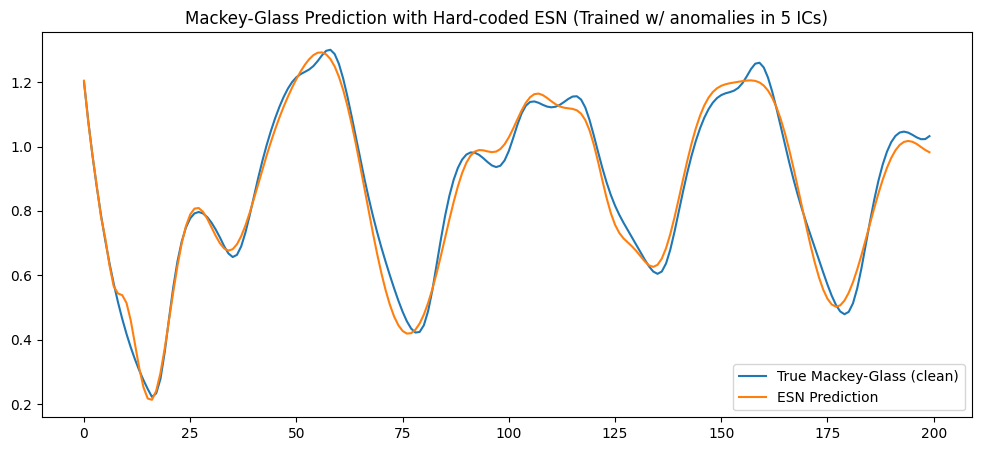

No persistent divergence detected (threshold=0.05, patience=10)


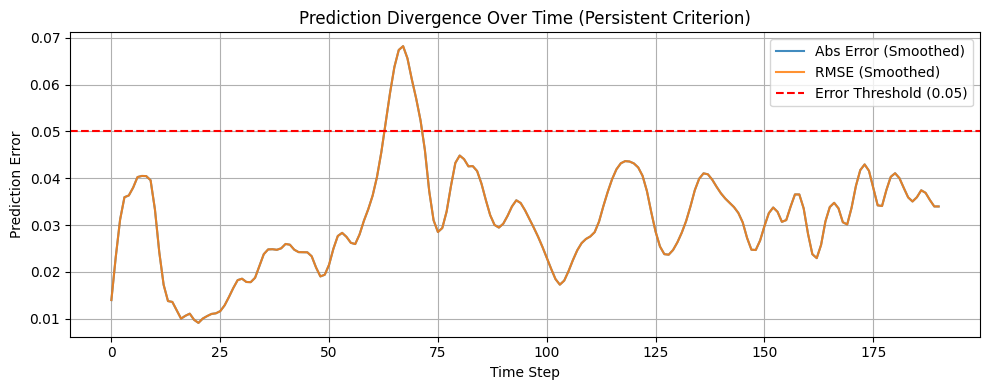


Test RMSE: 0.0366
Test R²:   0.9811
Pearson correlation: 0.9908
Spearman correlation: 0.9899
Spectral cosine similarity: 0.9996


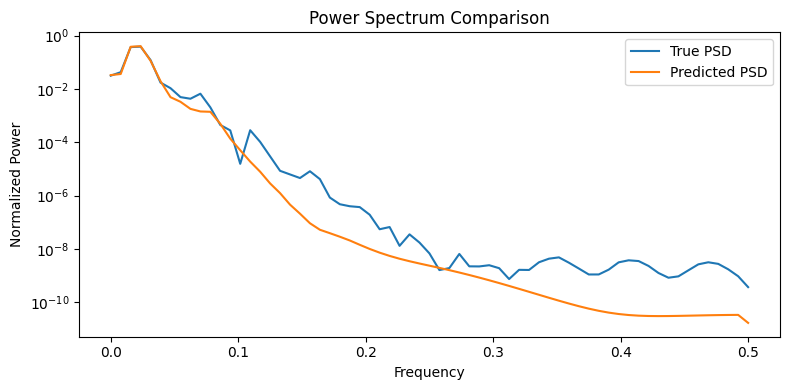

F-statistic: 5125.9390
P-value:     1.1102e-16

--- Memory Usage ---
CPU RAM used: 1603.04 MB
Current GPU memory allocated: 19.05 MB
Peak GPU memory allocated: 19.06 MB


In [13]:




import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import f
from time import time
import math
import random
import torch
import psutil
import os

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

def get_cpu_ram_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**2  # MB

def get_gpu_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024**2
    return 0

def get_gpu_peak_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1024**2
    return 0

# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1])
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Function to insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.05, anomaly_scale=0.5):
    """
    Insert anomalies into a time series.
    anomaly_rate: fraction of points that are anomalous
    anomaly_scale: magnitude of anomalies
    """
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)

    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.2
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data (with anomalies on 5 sequences) ---
X_list, y_list = [], []
rng = np.random.default_rng()  # independent generator (no fixed seed)
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)  # insert anomalies
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

# --- Generate test data (clean) ---
x_test = mackey_glass(t_max=t_max, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test


# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Hard-coded Reservoir ---
start_time = time()
np.random.seed(42)
n_reservoir = 2500
n_input = X_scaled.shape[1]
spectral_radius = 1.0
lr = 0.5  # leak rate

# Input weights
Win = np.random.uniform(-1, 1, (n_reservoir, n_input))
# Reservoir weights
W = np.random.uniform(-1, 1, (n_reservoir, n_reservoir))
# Scale to spectral radius
rho_W = max(abs(np.linalg.eigvals(W)))
W *= spectral_radius / rho_W

# --- Collect reservoir states for training ---
def run_reservoir(X_seq):
    T = X_seq.shape[0]
    states = np.zeros((T, n_reservoir))
    x = np.zeros(n_reservoir)
    for t in range(T):
        u = X_seq[t]
        x = (1 - lr) * x + lr * np.tanh(np.dot(Win, u) + np.dot(W, x))
        states[t] = x
    return states

# Reshape training sequences
n_train = len(train_ics)
X_rnn_states = []
y_rnn_targets = []
for i in range(n_train):
    states = run_reservoir(X_scaled[i*t_max:(i+1)*t_max])
    X_rnn_states.append(states)
    y_rnn_targets.append(y[i*t_max:(i+1)*t_max].reshape(-1, 1))

X_states_train = np.vstack(X_rnn_states)
y_train = np.vstack(y_rnn_targets)

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

# --- Train readout (Ridge Regression) ---
ridge = Ridge(alpha=1e-7)
ridge.fit(X_states_train, y_train)

# --- Test ---
X_states_test = run_reservoir(X_test_scaled)
y_pred = ridge.predict(X_states_test).flatten()

washout = 0

# --- Metrics ---
rmse = np.sqrt(mean_squared_error(y_test[washout:], y_pred[washout:]))
r2 = r2_score(y_test[washout:], y_pred[washout:])
print("RMSE:", rmse)
print("R^2:", r2)

plt.figure(figsize=(12,5))
plt.plot(y_test[washout:], label='True Mackey-Glass (clean)')
plt.plot(y_pred[washout:], label='ESN Prediction')
plt.legend()
plt.title('Mackey-Glass Prediction with Hard-coded ESN (Trained w/ anomalies in 5 ICs)')
plt.show()



from sklearn.metrics import mean_squared_error, r2_score
# Divergence
pred_test = y_pred
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

import numpy as np
import matplotlib.pyplot as plt

errors = np.abs(pred_test - y_test)
rmse = np.sqrt((pred_test - y_test) ** 2)

def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse, w=window_size)

threshold = 0.05
patience = 10

above = smoothed_error > threshold
divergence_time = None

for t in range(len(above) - patience):
    if above[t] and np.all(above[t:t + patience]):
        divergence_time = t
        break

if divergence_time is None:
    print(f"No persistent divergence detected (threshold={threshold}, patience={patience})")
else:
    print(f"Prediction horizon (persistent divergence): {divergence_time} steps")

plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.85)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.85)
plt.axhline(y=threshold, color="r", linestyle="--", label=f"Error Threshold ({threshold})")

if divergence_time is not None:
    plt.axvline(divergence_time, linestyle="--", alpha=0.7)

    x_min, x_max = 0, len(smoothed_error)
    y_min, y_max = 0, max(smoothed_error) * 1.1

    x_text = divergence_time + 10
    if x_text > x_max - 20:
        x_text = divergence_time - 20
    x_text = np.clip(x_text, x_min, x_max)

    y_text = smoothed_error[divergence_time] + 0.03
    y_text = np.clip(y_text, y_min, y_max)

    plt.annotate(
        f"Divergence: {divergence_time} steps",
        xy=(divergence_time, smoothed_error[divergence_time]),
        xytext=(x_text, y_text),
        arrowprops=dict(arrowstyle="->"),
        fontsize=10
    )

plt.title("Prediction Divergence Over Time (Persistent Criterion)")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")


from scipy.stats import pearsonr, spearmanr

def correlation_metrics(y_true, y_pred):
    pearson_corr, _ = pearsonr(y_true, y_pred)
    spearman_corr, _ = spearmanr(y_true, y_pred)
    return pearson_corr, spearman_corr

pearson_corr, spearman_corr = correlation_metrics(y_test, pred_test)
print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")


from scipy.signal import welch
from numpy.linalg import norm

def spectral_similarity(y_true, y_pred, fs=1.0):
    # Welch’s method for power spectral density (PSD)
    f_true, Pxx_true = welch(y_true, fs=fs, nperseg=128)
    f_pred, Pxx_pred = welch(y_pred, fs=fs, nperseg=128)

    # Normalize
    Pxx_true /= np.sum(Pxx_true)
    Pxx_pred /= np.sum(Pxx_pred)

    # Cosine similarity
    cosine_sim = np.dot(Pxx_true, Pxx_pred) / (norm(Pxx_true) * norm(Pxx_pred))
    return cosine_sim, f_true, Pxx_true, Pxx_pred

cos_sim, f, spec_true, spec_pred = spectral_similarity(y_test, pred_test)
print(f"Spectral cosine similarity: {cos_sim:.4f}")

# Plot spectra
plt.figure(figsize=(8,4))
plt.semilogy(f, spec_true, label="True PSD")
plt.semilogy(f, spec_pred, label="Predicted PSD")
plt.title("Power Spectrum Comparison")
plt.xlabel("Frequency")
plt.ylabel("Normalized Power")
plt.legend()
plt.tight_layout()
plt.show()


from scipy.stats import f as f_dist

# --- F-statistic and p-value ---
n = len(y_test)
k = X_test.shape[1]  # number of predictors = 2
F_stat = (r2 / k) / ((1 - r2) / (n - k - 1))
p_value = 1 - f_dist.cdf(F_stat, k, n - k - 1)

print(f"F-statistic: {F_stat:.4f}")
print(f"P-value:     {p_value:.4e}")


cpu_ram = get_cpu_ram_mb()
gpu_mem = get_gpu_mem_mb()
gpu_peak = get_gpu_peak_mem_mb()

print("\n--- Memory Usage ---")
print(f"CPU RAM used: {cpu_ram:.2f} MB")

if torch.cuda.is_available():
    print(f"Current GPU memory allocated: {gpu_mem:.2f} MB")
    print(f"Peak GPU memory allocated: {gpu_peak:.2f} MB")
else:
    print("GPU not available")